# Figure Generation
Run all cells to regenerate manuscript figures. Output → `../figures/`.

In [2]:
import pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import matplotlib.ticker as mtick

project_root = pathlib.Path.cwd().parent
figures_dir = project_root / "figures"
figures_dir.mkdir(parents=True, exist_ok=True)

In [3]:
# Scenario parameters (adjusted post-AGU)
scenario_params = {
    "S1": {
        "Name": "Big Brother is Watching",
        "r": 0.0020, "R0_mean": 400, "delta_mean": 1.2,
        "cf_mean": 0.6, "rd_mean": 40, "rf_mean": 0.15, "h_ex_risk": 0.003,
    },
    "S2": {
        "Name": "Wild West",
        "r": 0.0026, "R0_mean": 700, "delta_mean": 1.5,
        "cf_mean": 0.3, "rd_mean": 70, "rf_mean": 0.10, "h_ex_risk": 0.001,
    },
    "S3": {
        "Name": "Golden Age",
        "r": 0.0001, "R0_mean": 2400, "delta_mean": 0.0,
        "cf_mean": 1.0, "rd_mean": 0, "rf_mean": 1.0, "h_ex_risk": 0.0,
    },
    "S4": {
        "Name": "Living with the Land",
        "r": 0.0060, "R0_mean": 600, "delta_mean": 2.5,
        "cf_mean": 0.2, "rd_mean": 100, "rf_mean": 0.10, "h_ex_risk": 0.0,
    },
    "S5": {
        "Name": "Transhumanism",
        "r": 0.0003, "R0_mean": 2500, "delta_mean": 0.1,
        "cf_mean": 0.9, "rd_mean": 20, "rf_mean": 0.80, "h_ex_risk": 0.0005,
    },
    "S6": {
        "Name": "Sword of Damocles",
        "r": 0.0018, "R0_mean": 1600, "delta_mean": 1.0,
        "cf_mean": 0.4, "rd_mean": 50, "rf_mean": 0.25, "h_ex_risk": 0.005,
    },
    "S7": {
        "Name": "Restoration",
        "r": 0.0060, "R0_mean": 400, "delta_mean": 1.5,
        "cf_mean": 0.3, "rd_mean": 60, "rf_mean": 0.20, "h_ex_risk": 0.001,
    },
    "S8": {
        "Name": "Ouroboros",
        "r": 0.0015, "R0_mean": 800, "delta_mean": 1.3,
        "cf_mean": 0.6, "rd_mean": 70, "rf_mean": 0.35, "h_ex_risk": 0.0,
    },
    "S9": {
        "Name": "Deus Ex Machina",
        "r": 0.0011, "R0_mean": 900, "delta_mean": 1.3,
        "cf_mean": 0.5, "rd_mean": 70, "rf_mean": 0.35, "h_ex_risk": 0.00,
    },
    "S10": {
        "Name": "Out of Eden",
        "r": 0.0002, "R0_mean": 2700, "delta_mean": 0.0,
        "cf_mean": 1.0, "rd_mean": 0, "rf_mean": 1.0, "h_ex_risk": 0.0,
    },
}

In [4]:
# Monte Carlo uncertainty fractions
frac_R0    = 0.05   # ±5% normal noise on initial resources
frac_delta = 0.05   # ±5% normal noise on depletion rate
frac_cf    = 0.05   # ±5% triangular noise on collapse depth
std_rd     = 10     # ±10 yr normal noise on recovery delay
frac_rf    = 0.05   # ±5% triangular noise on recovery fraction

lifespan   = 1000
replicates = 200
rng        = np.random.default_rng(12345)


def safe_triangular(rng, center, frac, min_val=0, max_val=1):
    """Triangular sampling; returns fixed value when frac=0 or bounds degenerate."""
    if frac == 0:
        return center
    left  = max(min_val, center * (1 - frac))
    right = min(max_val, center * (1 + frac))
    if np.isclose(left, right):
        return center
    return np.clip(rng.triangular(left, center, right), min_val, max_val)


def simulate_run(r, R0, delta, cf, rd, rf, h, rng):
    """Single-run simulator with linear growth, resource depletion, and existential risk."""
    T, R = 1.0, R0
    in_collapse, timer = False, 0
    tech_ts = np.empty(lifespan)
    res_ts  = np.empty(lifespan)
    collapse_events = []

    for t in range(lifespan):
        if in_collapse:
            timer += 1
            if timer >= rd:
                R = R0 * rf
                in_collapse = False
                timer = 0
        else:
            T += r
            R -= delta
            if rng.random() < h:
                R = 0
            if R <= 0:
                R = 0
                in_collapse = True
                timer = 0
                T *= cf
                collapse_events.append(t)

        tech_ts[t] = T
        res_ts[t]  = R

    first_collapse = collapse_events[0] if collapse_events else lifespan
    duty_cycle     = np.sum(res_ts > 0) / lifespan
    n_cycles       = len(collapse_events)
    return tech_ts, res_ts, first_collapse, n_cycles, duty_cycle


# Monte Carlo loop
records     = []
tech_curves = {}
res_curves  = {}

for code_name, p in scenario_params.items():
    tech_runs, res_runs = [], []
    Ls, Cs, Ds = [], [], []

    for _ in range(replicates):
        R0    = max(1.0, rng.normal(p["R0_mean"], frac_R0 * p["R0_mean"])) if frac_R0 > 0 else p["R0_mean"]
        delta = max(0.0, rng.normal(p["delta_mean"], frac_delta * p["delta_mean"])) if frac_delta > 0 else p["delta_mean"]
        cf    = safe_triangular(rng, p["cf_mean"], frac_cf)
        rf    = safe_triangular(rng, p["rf_mean"], frac_rf)
        rd    = max(0, rng.normal(p["rd_mean"], std_rd)) if std_rd > 0 else p["rd_mean"]

        tech_ts, res_ts, L, C, D = simulate_run(p["r"], R0, delta, cf, rd, rf, p["h_ex_risk"], rng)
        tech_runs.append(tech_ts)
        res_runs.append(res_ts)
        Ls.append(L); Cs.append(C); Ds.append(D)

    tech_curves[code_name] = np.vstack(tech_runs)
    res_curves[code_name]  = np.vstack(res_runs)

    records.append({
        "Scenario":             code_name,
        "Name":                 p["Name"],
        "Mean_Collapse":        np.mean(Ls),
        "Std_Collapse":         np.std(Ls),
        "Never_Collapsed_Frac": np.mean([l == lifespan for l in Ls]),
        "Mean_Duty_Cycle":      np.mean(Ds),
        "Std_Duty_Cycle":       np.std(Ds),
        "Mean_Cycles":          np.mean(Cs),
        "Std_Cycles":           np.std(Cs),
    })

summary_df = pd.DataFrame(records)
print(summary_df.to_string(index=False))

Scenario                    Name  Mean_Collapse  Std_Collapse  Never_Collapsed_Frac  Mean_Duty_Cycle  Std_Duty_Cycle  Mean_Cycles  Std_Cycles
      S1 Big Brother is Watching        205.840    124.067540                 0.000         0.622645        0.077842        9.755    1.927427
      S2               Wild West        383.215    148.491814                 0.000         0.613685        0.093672        5.840    1.369087
      S3              Golden Age       1000.000      0.000000                 1.000         1.000000        0.000000        0.000    0.000000
      S4    Living with the Land        240.625     17.212913                 0.000         0.380990        0.024875        6.600    0.616441
      S5           Transhumanism        810.590    299.296462                 0.635         0.990650        0.015227        0.450    0.676387
      S6       Sword of Damocles        169.480    156.792250                 0.000         0.785375        0.069763        4.460    1.370547
      

/var/folders/38/2zkx65c923d5y4297z_j_w0r0000gn/T/ipykernel_74751/139688638.py:38: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


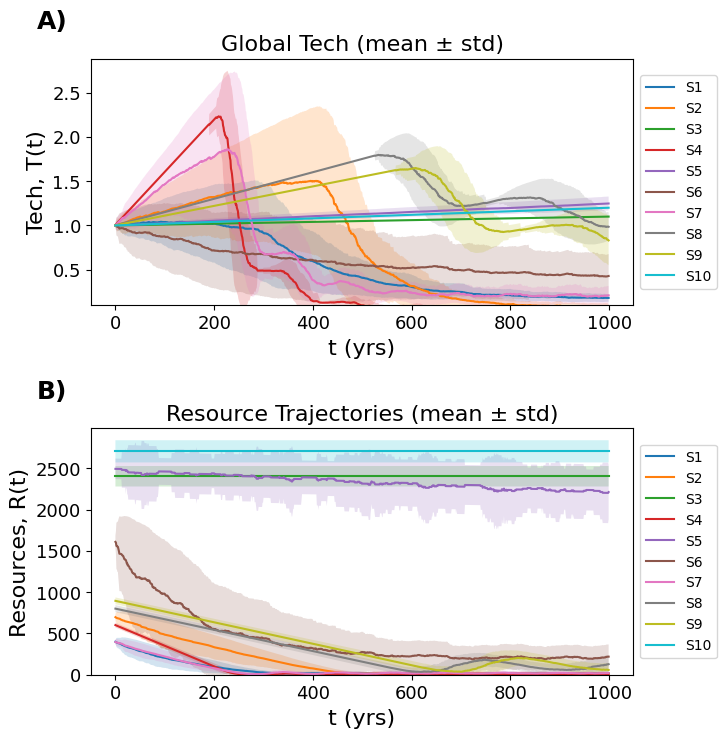

In [5]:
# Figure 1: Tech and resource trajectories (mean +/- std)
fig = plt.figure(figsize=(7, 8))
gs = GridSpec(2, 1, figure=fig, hspace=0.5)
ticks = np.arange(lifespan)

ax1 = fig.add_subplot(gs[0])
for s in scenario_params:
    mu = tech_curves[s].mean(axis=0)
    sd = tech_curves[s].std(axis=0)
    ax1.plot(ticks, mu, label=s)
    ax1.fill_between(ticks, mu - sd, mu + sd, alpha=0.2)
ax1.set_ylabel("Tech, T(t)", fontsize=16)
ax1.set_xlabel("t (yrs)", fontsize=16)
ax1.set_ylim(0.1)
ax1.set_title("Global Tech (mean ± std)", fontsize=16)
ax1.legend(fontsize=10, loc="center left", bbox_to_anchor=(1, 0.5))
ax1.text(-0.1, 1.2, "A)", transform=ax1.transAxes, fontsize=18, fontweight="bold", va="top")

ax2 = fig.add_subplot(gs[1])
for s in scenario_params:
    mu = res_curves[s].mean(axis=0)
    sd = res_curves[s].std(axis=0)
    ax2.plot(ticks, mu, label=s)
    ax2.fill_between(ticks, mu - sd, mu + sd, alpha=0.2)
ax2.set_ylabel("Resources, R(t)", fontsize=16)
ax2.set_xlabel("t (yrs)", fontsize=16)
ax2.set_ylim(0)
ax2.set_title("Resource Trajectories (mean ± std)", fontsize=16)
ax2.legend(fontsize=10, loc="center left", bbox_to_anchor=(1, 0.5))
ax2.text(-0.1, 1.2, "B)", transform=ax2.transAxes, fontsize=18, fontweight="bold", va="top")

for ax in [ax1, ax2]:
    ax.tick_params(labelsize=13)

    for spine in ax.spines.values():
        spine.set_visible(True); spine.set_color("black"); spine.set_linewidth(0.8)

plt.tight_layout()
plt.savefig(figures_dir / "figure1.png", dpi=300, bbox_inches="tight")
plt.show()

/var/folders/38/2zkx65c923d5y4297z_j_w0r0000gn/T/ipykernel_74751/1389812292.py:38: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df["Label"], rotation=0, ha="center")
/var/folders/38/2zkx65c923d5y4297z_j_w0r0000gn/T/ipykernel_74751/1389812292.py:38: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df["Label"], rotation=0, ha="center")
/var/folders/38/2zkx65c923d5y4297z_j_w0r0000gn/T/ipykernel_74751/1389812292.py:38: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df["Label"], rotation=0, ha="center")
/var/folders/38/2zkx65c923d5y4297z_j_w0r0000gn/T/ipykernel_74751/1389812292.py:38: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or u

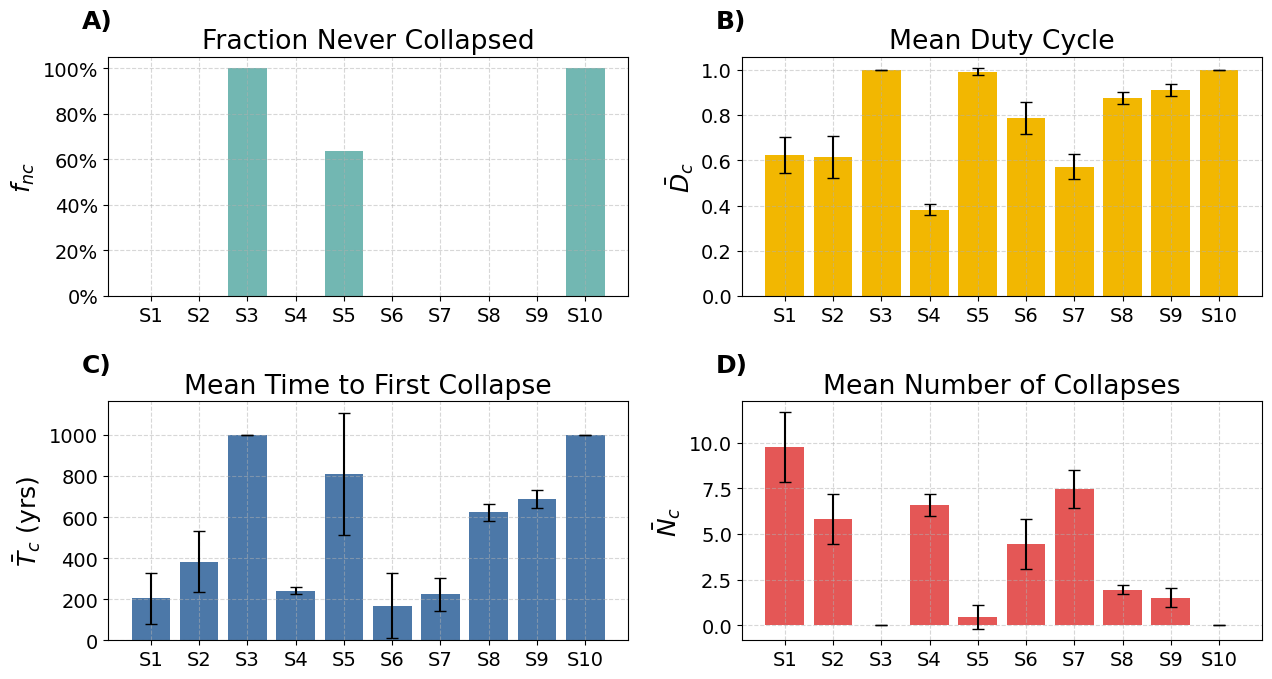

In [6]:
# Figure 3: Summary metrics panel
df = summary_df.copy()
df["Label"] = df["Scenario"]

plt.rcParams.update({
    "font.family": "DejaVu Sans", "font.size": 16,
    "axes.edgecolor": "black", "axes.facecolor": "white",
    "figure.facecolor": "white",
})

colors = ["#72B7B2", "#F2B701", "#4C78A8", "#E45756"]
fig, axs = plt.subplots(2, 2, figsize=(13, 7.5))
axs = axs.flatten()
panel_labels = ["A)", "B)", "C)", "D)"]

# A: Fraction never collapsed
axs[0].bar(df["Label"], df["Never_Collapsed_Frac"], color=colors[0])
axs[0].set_ylabel(r"$f_{nc}$", fontsize=18)
axs[0].set_title("Fraction Never Collapsed")
axs[0].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

# B: Mean duty cycle
axs[1].bar(df["Label"], df["Mean_Duty_Cycle"], yerr=df["Std_Duty_Cycle"], capsize=4, color=colors[1])
axs[1].set_ylabel(r"$\bar{D}_{c}$", fontsize=18)
axs[1].set_title("Mean Duty Cycle")

# C: Mean time to first collapse
axs[2].bar(df["Label"], df["Mean_Collapse"], yerr=df["Std_Collapse"], capsize=4, color=colors[2])
axs[2].set_ylabel(r"$\bar{T}_{c}$ (yrs)", fontsize=18)
axs[2].set_title("Mean Time to First Collapse")

# D: Mean number of collapses
axs[3].bar(df["Label"], df["Mean_Cycles"], yerr=df["Std_Cycles"], capsize=4, color=colors[3])
axs[3].set_ylabel(r"$\bar{N}_{c}$", fontsize=18)
axs[3].set_title("Mean Number of Collapses")

for ax, label in zip(axs, panel_labels):
    ax.set_xticklabels(df["Label"], rotation=0, ha="center")
    ax.tick_params(labelsize=14)
    ax.grid(True, linestyle="--", alpha=0.5)
    for spine in ax.spines.values():
        spine.set_visible(True); spine.set_color("black"); spine.set_linewidth(0.8)
    ax.text(-0.05, 1.2, label, transform=ax.transAxes, fontsize=18, fontweight="bold", va="top", ha="left")

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig(figures_dir / "figure3.png", dpi=300, bbox_inches="tight")
plt.show()


/var/folders/38/2zkx65c923d5y4297z_j_w0r0000gn/T/ipykernel_74751/1690475752.py:37: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df["Label"], rotation=0, ha="center")
/var/folders/38/2zkx65c923d5y4297z_j_w0r0000gn/T/ipykernel_74751/1690475752.py:37: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df["Label"], rotation=0, ha="center")
/var/folders/38/2zkx65c923d5y4297z_j_w0r0000gn/T/ipykernel_74751/1690475752.py:37: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df["Label"], rotation=0, ha="center")
/var/folders/38/2zkx65c923d5y4297z_j_w0r0000gn/T/ipykernel_74751/1690475752.py:37: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or u

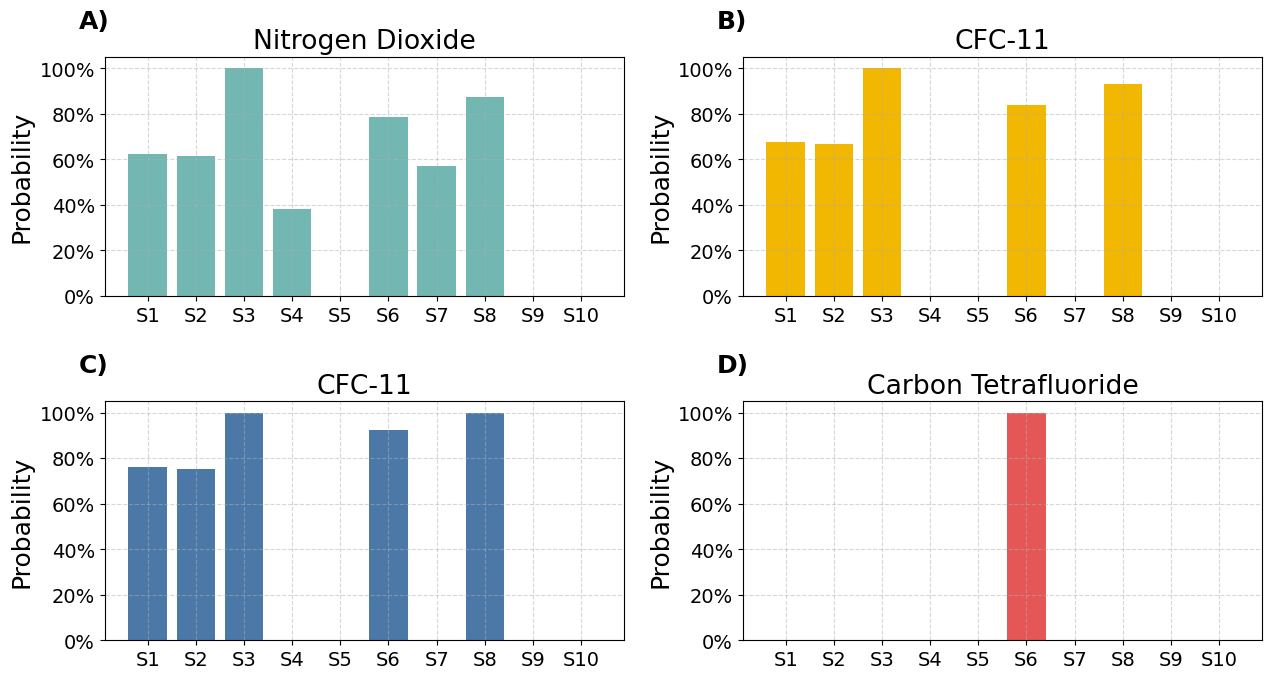

In [7]:
# Figure X: Technosignature detectability panel

colors = ["#72B7B2", "#F2B701", "#4C78A8", "#E45756"]
fig, axs = plt.subplots(2, 2, figsize=(13, 7.5))
axs = axs.flatten()
panel_labels = ["A)", "B)", "C)", "D)"]

# A: Nitrogen Dioxide
present = [1,1,1,1,0,1,1,1,0,0]
axs[0].bar(df["Label"], df["Mean_Duty_Cycle"] * present, color=colors[0])
axs[0].set_ylabel("Probability", fontsize=18)
axs[0].set_title("Nitrogen Dioxide")
axs[0].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

# B: CFC-11
present = [1,1,1,0,0,1,0,1,0,0]
axs[1].bar(df["Label"], (df["Mean_Duty_Cycle"] + np.minimum(55./1000., 1.0-df["Mean_Duty_Cycle"]) )*present, color=colors[1])
axs[1].set_ylabel("Probability", fontsize=18)
axs[1].set_title("CFC-11")
axs[1].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

# C: CFC-12
present = [1,1,1,0,0,1,0,1,0,0]
axs[2].bar(df["Label"], (df["Mean_Duty_Cycle"] + np.minimum(140./1000., 1.0-df["Mean_Duty_Cycle"]) )*present, color=colors[2])
axs[2].set_ylabel("Probability", fontsize=18)
axs[2].set_title("CFC-11")
axs[2].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

# D: Carbon Tetrafluoride
present = [0,0,0,0,0,1,0,0,0,0]
axs[3].bar(df["Label"], (df["Mean_Duty_Cycle"] + np.minimum(1000./1000., 1.0-df["Mean_Duty_Cycle"]) )*present, color=colors[3])
axs[3].set_ylabel("Probability", fontsize=18)
axs[3].set_title("Carbon Tetrafluoride")
axs[3].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

for ax, label in zip(axs, panel_labels):
    ax.set_xticklabels(df["Label"], rotation=0, ha="center")
    ax.tick_params(labelsize=14)
    ax.grid(True, linestyle="--", alpha=0.5)
    for spine in ax.spines.values():
        spine.set_visible(True); spine.set_color("black"); spine.set_linewidth(0.8)
    ax.text(-0.05, 1.2, label, transform=ax.transAxes, fontsize=18, fontweight="bold", va="top", ha="left")

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig(figures_dir / "figure6.png", dpi=300, bbox_inches="tight")
plt.show()


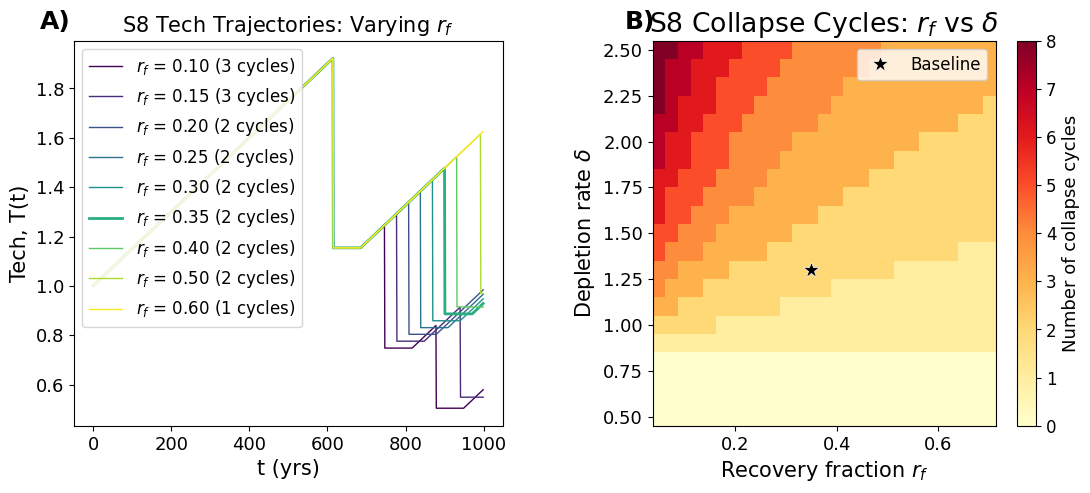

Cycle grid: min=0, max=8


In [8]:
# Figure 2: S8 (Ouroboros) parameter sweep — oscillatory regime sensitivity
S8 = scenario_params["S8"]

def simulate_deterministic(r, R0, delta, cf, rd, rf, h=0.0):
    """Single deterministic run (no stochastic noise)."""
    T, R = 1.0, R0
    in_c, timer = False, 0
    tech_ts = np.empty(lifespan)
    res_ts  = np.empty(lifespan)
    cycles  = 0
    for t in range(lifespan):
        if in_c:
            timer += 1
            if timer >= rd:
                R = R0 * rf; in_c = False; timer = 0
        else:
            T += r; R -= delta
            if R <= 0:
                R = 0; in_c = True; timer = 0; T *= cf; cycles += 1
        tech_ts[t] = T; res_ts[t] = R
    duty = np.sum(res_ts > 0) / lifespan
    return tech_ts, res_ts, cycles, duty

fig = plt.figure(figsize=(13, 5))
gs = GridSpec(1, 2, figure=fig, wspace=0.35)

# Panel A: T(t) for varying rf
ax1 = fig.add_subplot(gs[0])
rf_values = [0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.50, 0.60]
cmap = plt.cm.viridis
colors_rf = [cmap(i / (len(rf_values) - 1)) for i in range(len(rf_values))]

for rf_val, c in zip(rf_values, colors_rf):
    tech, _, cyc, _ = simulate_deterministic(
        S8["r"], S8["R0_mean"], S8["delta_mean"], S8["cf_mean"], S8["rd_mean"], rf_val
    )
    lw = 2.0 if rf_val == S8["rf_mean"] else 1.0
    ax1.plot(np.arange(lifespan), tech, color=c, lw=lw,
             label=f"$r_f$ = {rf_val:.2f} ({cyc} cycles)")

ax1.set_xlabel("t (yrs)", fontsize=15)
ax1.set_ylabel("Tech, T(t)", fontsize=15)
ax1.set_title("S8 Tech Trajectories: Varying $r_f$", fontsize=15)
ax1.legend(fontsize=12, loc="upper left")
ax1.text(-0.08, 1.08, "A)", transform=ax1.transAxes, fontsize=18, fontweight="bold", va="top")
ax1.tick_params(labelsize=13)
for spine in ax1.spines.values():
    spine.set_visible(True); spine.set_color("black"); spine.set_linewidth(0.8)

# Panel B: Heatmap of cycles vs (rf, delta)
ax2 = fig.add_subplot(gs[1])
rf_range    = np.arange(0.05, 0.71, 0.025)
delta_range = np.arange(0.5, 2.51, 0.1)
cycle_grid  = np.zeros((len(delta_range), len(rf_range)))

for i, d in enumerate(delta_range):
    for j, rf in enumerate(rf_range):
        _, _, cyc, _ = simulate_deterministic(
            S8["r"], S8["R0_mean"], d, S8["cf_mean"], S8["rd_mean"], rf
        )
        cycle_grid[i, j] = cyc

im = ax2.pcolormesh(rf_range, delta_range, cycle_grid, cmap="YlOrRd", shading="nearest")
fig.colorbar(im, ax=ax2, label="Number of collapse cycles"); im.colorbar = None  # fontsize set below
cb = fig.axes[-1]; cb.tick_params(labelsize=12); cb.set_ylabel("Number of collapse cycles", fontsize=13)
ax2.plot(S8["rf_mean"], S8["delta_mean"], "k*", markersize=12,
         markeredgecolor="white", markeredgewidth=0.5, label="Baseline")
ax2.set_xlabel("Recovery fraction $r_f$", fontsize=15)
ax2.set_ylabel("Depletion rate $\\delta$", fontsize=15)
ax2.set_title("S8 Collapse Cycles: $r_f$ vs $\\delta$")
ax2.legend(fontsize=12, loc="upper right")
ax2.text(-0.08, 1.08, "B)", transform=ax2.transAxes, fontsize=18, fontweight="bold", va="top")
ax2.tick_params(labelsize=13)
for spine in ax2.spines.values():
    spine.set_visible(True); spine.set_color("black"); spine.set_linewidth(0.8)

plt.savefig(figures_dir / "figure2.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"Cycle grid: min={cycle_grid.min():.0f}, max={cycle_grid.max():.0f}")

In [9]:
# Parameter sweep definitions (used by Figure S1 and Figure 5)
# c_f excluded: response curves show negligible effect on all metrics (see SI)
param_sweeps = {
    r"$r_f$":      {"key": "rf",    "low": 0.10, "high": 0.80},
    r"$\delta$":   {"key": "delta", "low": 0.1,  "high": 2.5},
    r"$r_d$":      {"key": "rd",    "low": 5,    "high": 100},
    r"$h$":        {"key": "h",     "low": 0.0,  "high": 0.005},
}
param_order = list(param_sweeps.keys())

param_colors = {label: c for label, c in zip(param_order,
                ["#4C78A8", "#F58518", "#E45756", "#54A24B"])}


def run_mc_batch(params, n=200, seed_rng=None):
    """Run Monte Carlo batch and return mean metrics."""
    _rng = seed_rng or np.random.default_rng()
    Ls, Cs, Ds = [], [], []
    for _ in range(n):
        R0    = max(1.0, _rng.normal(params["R0"], frac_R0 * params["R0"]))
        delta = max(0.0, _rng.normal(params["delta"], frac_delta * params["delta"])) if params["delta"] > 0 else 0.0
        cf    = safe_triangular(_rng, params["cf"], frac_cf)
        rf    = safe_triangular(_rng, params["rf"], frac_rf)
        rd    = max(0, _rng.normal(params["rd"], std_rd)) if params["rd"] > 0 else 0.0
        _, _, L, C, D = simulate_run(params["r"], R0, delta, cf, rd, rf, params["h"], _rng)
        Ls.append(L); Cs.append(C); Ds.append(D)
    return {
        "Dc": np.mean(Ds), "Tc": np.mean(Ls),
        "Nc": np.mean(Cs), "fnc": np.mean([l == lifespan for l in Ls]),
    }


metric_info = [
    ("Dc", r"Duty Cycle $\bar{D}_c$"),
    ("Tc", r"Time to First Collapse $\bar{T}_c$ (yrs)"),
    ("Nc", r"Collapse Cycles $\bar{N}_c$"),
    ("fnc", r"Never-Collapse Fraction $f_{nc}$"),
]
metric_xlims = {"Dc": (-0.02, 1.02), "fnc": (-0.02, 1.02), "Nc": (0, None), "Tc": (0, None)}

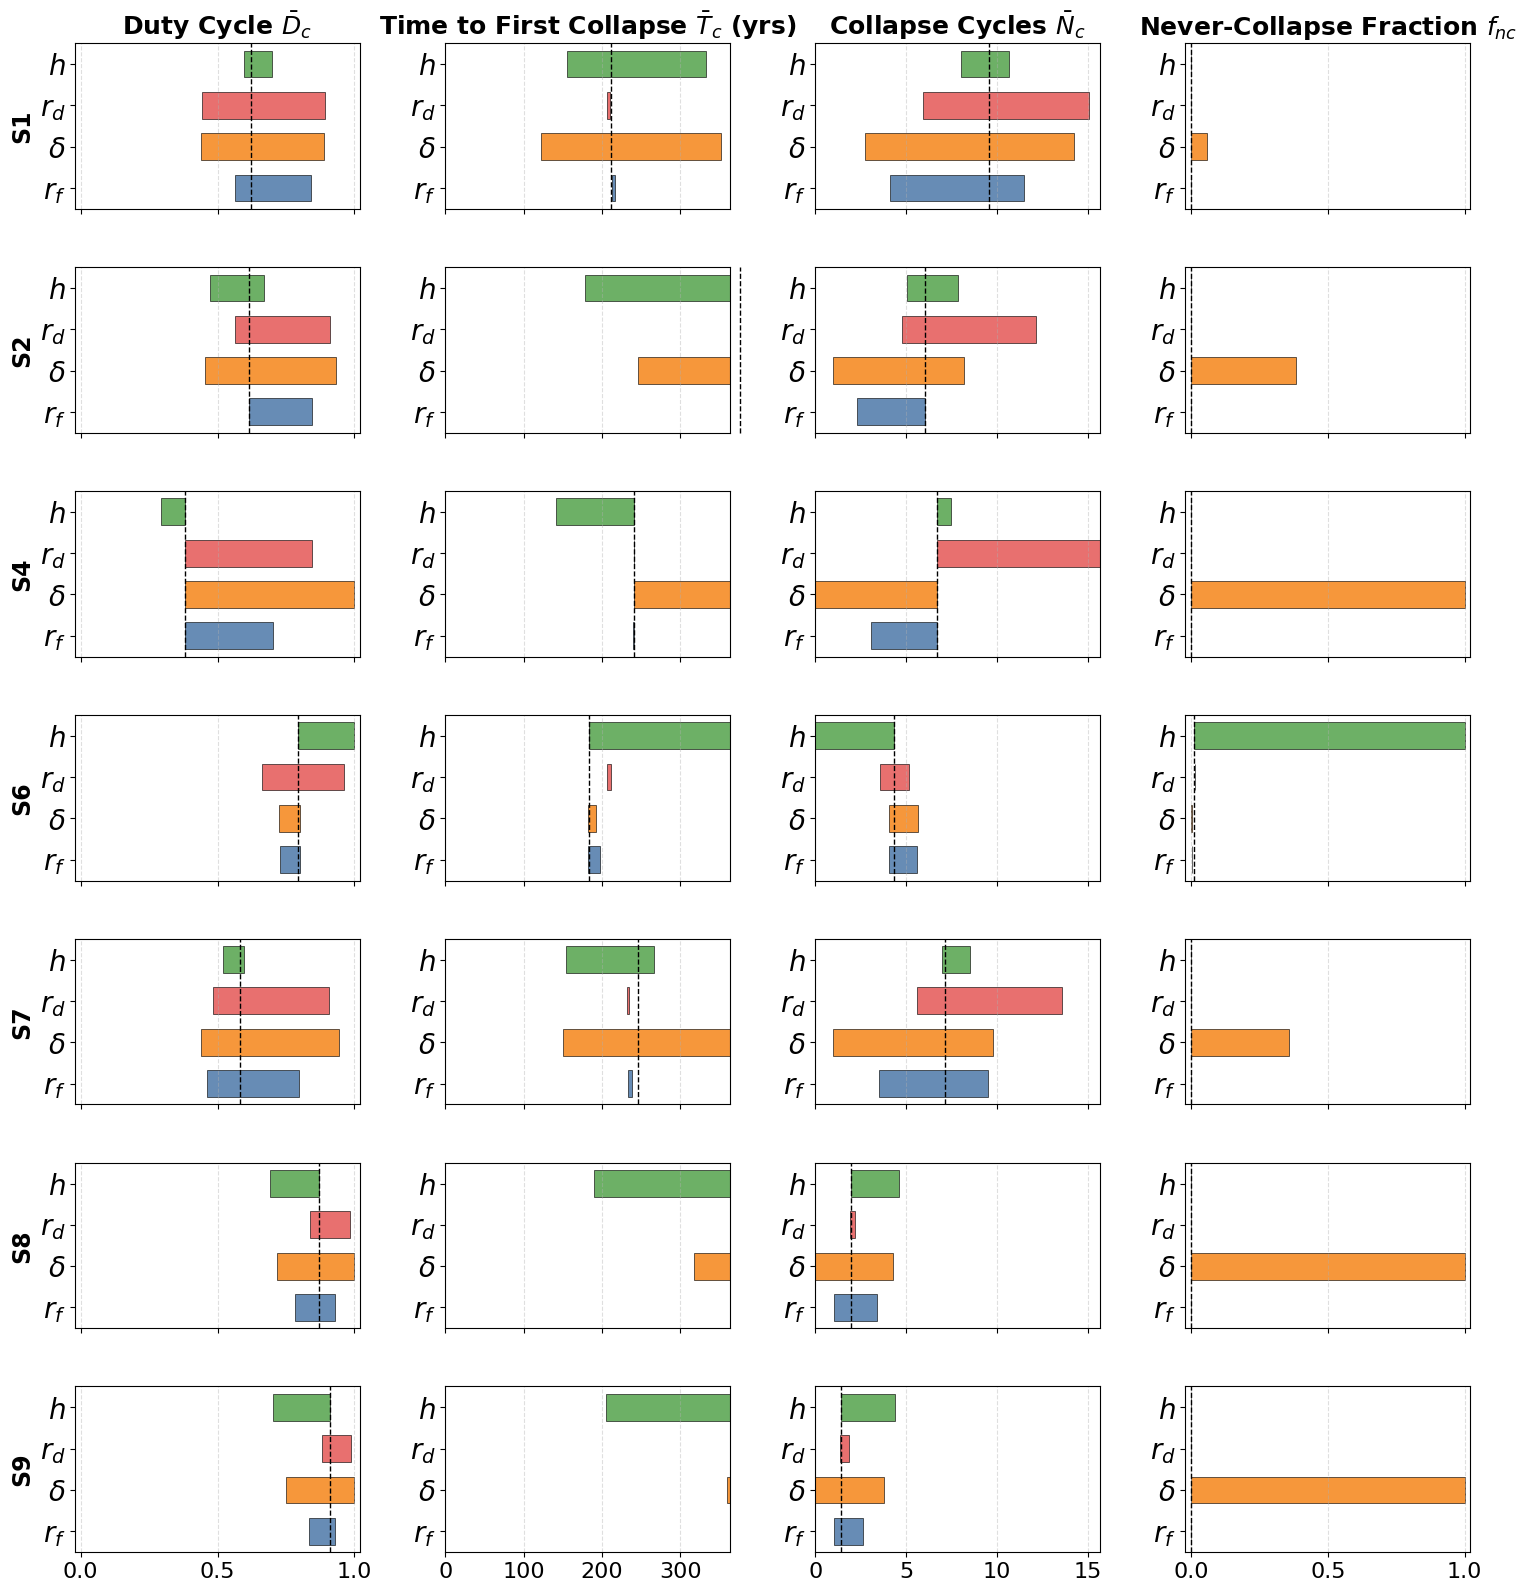

In [10]:
# Supplementary Figure S1: Sensitivity analysis for ALL collapse-prone scenarios
collapse_scenarios = ["S1", "S2", "S4", "S6", "S7", "S8", "S9"]

fig, axes = plt.subplots(len(collapse_scenarios), 4, figsize=(18, 2.8 * len(collapse_scenarios)),
                         sharex="col",
                         gridspec_kw={"hspace": 0.35, "wspace": 0.30})

for row, sc in enumerate(collapse_scenarios):
    sp = scenario_params[sc]
    sc_baseline = {
        "r": sp["r"], "R0": sp["R0_mean"], "delta": sp["delta_mean"],
        "cf": sp["cf_mean"], "rd": sp["rd_mean"], "rf": sp["rf_mean"],
        "h": sp["h_ex_risk"],
    }
    sc_base_metrics = run_mc_batch(sc_baseline, seed_rng=np.random.default_rng(54321))

    sc_sweep = {}
    for label, info in param_sweeps.items():
        key = info["key"]
        results = {}
        for bound_name, bound_val in [("low", info["low"]), ("high", info["high"])]:
            p = sc_baseline.copy()
            p[key] = bound_val
            results[bound_name] = run_mc_batch(p, seed_rng=np.random.default_rng(54321))
        sc_sweep[label] = results

    for col, (metric_key, metric_title) in enumerate(metric_info):
        ax = axes[row, col]
        base_val = sc_base_metrics[metric_key]
        y_pos = np.arange(len(param_order))

        for i, label in enumerate(param_order):
            lo = sc_sweep[label]["low"][metric_key]
            hi = sc_sweep[label]["high"][metric_key]
            left = min(lo, hi)
            width = abs(hi - lo)
            ax.barh(i, width, left=left, height=0.65, color=param_colors[label],
                    alpha=0.85, edgecolor="black", linewidth=0.5)

        if metric_key in metric_xlims:
            ax.set_xlim(metric_xlims[metric_key])
        ax.axvline(base_val, color="black", linestyle="--", linewidth=1.0,
                   zorder=5, clip_on=False)
        ax.set_yticks(y_pos)
        ax.set_yticklabels(param_order, fontsize=20)
        ax.tick_params(axis="x", labelsize=16)
        ax.grid(True, axis="x", linestyle="--", alpha=0.4)
        for spine in ax.spines.values():
            spine.set_visible(True); spine.set_color("black"); spine.set_linewidth(0.8)

        if row == 0:
            ax.set_title(metric_title, fontsize=18, fontweight="bold")
        if col == 0:
            ax.set_ylabel(sc, fontsize=17, fontweight="bold")



plt.savefig(figures_dir / "figure4.png", dpi=300, bbox_inches="tight")
plt.show()


In [11]:
# Figure 5: Response curves — D_c vs each controllable parameter, all collapse-prone scenarios
# 7 rows (scenarios) × 4 columns (parameters)
n_sweep = 20
collapse_scenarios = ["S1", "S2", "S4", "S6", "S7", "S8", "S9"]

# Spelled-out parameter names (red to highlight edits)
param_fullnames = {
    r"$r_f$":    r"Recovery fraction $r_f$",
    r"$\delta$": r"Depletion rate $\delta$",
    r"$r_d$":    r"Recovery delay $r_d$",
    r"$h$":      r"Existential hazard rate $h$",
}

fig, axes = plt.subplots(len(collapse_scenarios), len(param_order),
                         figsize=(18, 2.8 * len(collapse_scenarios)),
                         sharex="col", sharey=True)

for row, sc in enumerate(collapse_scenarios):
    sp = scenario_params[sc]
    bl = {
        "r": sp["r"], "R0": sp["R0_mean"], "delta": sp["delta_mean"],
        "cf": sp["cf_mean"], "rd": sp["rd_mean"], "rf": sp["rf_mean"],
        "h": sp["h_ex_risk"],
    }

    for col, label in enumerate(param_order):
        ax = axes[row, col]
        info = param_sweeps[label]
        key = info["key"]
        sweep_vals = np.linspace(info["low"], info["high"], n_sweep)
        means, stds = [], []

        for val in sweep_vals:
            p = bl.copy()
            p[key] = val
            _rng = np.random.default_rng(54321)
            Ds = []
            for _ in range(replicates):
                R0    = max(1.0, _rng.normal(p["R0"], frac_R0 * p["R0"]))
                delta = max(0.0, _rng.normal(p["delta"], frac_delta * p["delta"])) if p["delta"] > 0 else 0.0
                cf    = safe_triangular(_rng, p["cf"], frac_cf)
                rf    = safe_triangular(_rng, p["rf"], frac_rf)
                rd    = max(0, _rng.normal(p["rd"], std_rd)) if p["rd"] > 0 else 0.0
                _, _, _, _, D = simulate_run(p["r"], R0, delta, cf, rd, rf, p["h"], _rng)
                Ds.append(D)
            means.append(np.mean(Ds))
            stds.append(np.std(Ds))

        means = np.array(means)
        stds = np.array(stds)
        color = param_colors[label]

        ax.plot(sweep_vals, means, color=color, linewidth=2.0)
        ax.fill_between(sweep_vals, means - stds, means + stds, color=color, alpha=0.2)
        ax.axvline(bl[key], color="black", linestyle="--", linewidth=1.0, alpha=0.7)
        ax.set_ylim(-0.02, 1.05)
        ax.grid(True, linestyle="--", alpha=0.3)
        ax.tick_params(labelsize=16)
        for spine in ax.spines.values():
            spine.set_visible(True); spine.set_color("black"); spine.set_linewidth(0.6)

        # Column titles (top row only)
        if row == 0:
            ax.set_title(param_fullnames[label], fontsize=22, fontweight="bold")

        # Row labels (first column only)
        if col == 0:
            ax.set_ylabel(sc, fontsize=20, fontweight="bold")

        # X-axis labels (bottom row only)
        if row == len(collapse_scenarios) - 1:
            ax.set_xlabel(param_fullnames[label], fontsize=20)

# Shared y-axis label
fig.text(0.01, 0.5, r"Duty Cycle $\bar{D}_c$", va="center", rotation="vertical", fontsize=22)

plt.tight_layout(rect=[0.03, 0, 1, 1])
plt.savefig(figures_dir / "figure5.png", dpi=300, bbox_inches="tight")
plt.show()